In [6]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("aklimarimi/8-facial-expressions-for-yolo")
print("Path to dataset files:", path)

# Inspect structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # only show files 3 levels deep
        for f in files[:3]:
            print(f'{indent}  {f}')

Path to dataset files: /home/jtshi/.cache/kagglehub/datasets/aklimarimi/8-facial-expressions-for-yolo/versions/4
4/
  9 Facial Expressions you need/
    data.yaml
    valid/
      labels/
      images/
    train/
      labels/
      images/
    test/
      labels/
      images/


In [7]:
import yaml

yaml_path = f"{path}/9 Facial Expressions you need/data.yaml"

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

print(config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 9, 'names': ['angry', 'contempt', 'disgust', 'fear', 'happy', 'natural', 'sad', 'sleepy', 'surprised']}


In [8]:
import os

label_dir = f"{path}/9 Facial Expressions you need/train/labels"
sample_label = os.listdir(label_dir)[0]

with open(f"{label_dir}/{sample_label}", 'r') as f:
    print(f.read())

0 0.41215624999999995 0.326484375 0.7028437499999999 0.65296875


In [9]:
import os
from PIL import Image
from collections import Counter

base = f"{path}/9 Facial Expressions you need"
splits = ["train", "valid", "test"]
classes = ['angry', 'contempt', 'disgust', 'fear', 'happy', 'natural', 'sad', 'sleepy', 'surprised']

# 1. Count images per split
print("=== Image Counts ===")
for split in splits:
    img_dir = f"{base}/{split}/images"
    print(f"{split}: {len(os.listdir(img_dir))} images")

# 2. Class distribution from labels
print("\n=== Class Distribution ===")
for split in splits:
    label_dir = f"{base}/{split}/labels"
    class_counts = Counter()
    for lf in os.listdir(label_dir):
        with open(f"{label_dir}/{lf}") as f:
            for line in f:
                cls = int(line.strip().split()[0])
                class_counts[cls] += 1
    print(f"\n{split}:")
    for cls_id, count in sorted(class_counts.items()):
        print(f"  {classes[cls_id]}: {count}")

# 3. Check for corrupted images
print("\n=== Corrupted Images ===")
corrupted = []
for split in splits:
    img_dir = f"{base}/{split}/images"
    for f in os.listdir(img_dir):
        try:
            img = Image.open(f"{img_dir}/{f}")
            img.verify()
        except Exception:
            corrupted.append(f"{split}/{f}")
print(f"Corrupted: {corrupted if corrupted else 'None'}")

# 4. Image sizes
print("\n=== Image Sizes (sample) ===")
for split in ["train"]:
    img_dir = f"{base}/{split}/images"
    sizes = []
    for f in os.listdir(img_dir)[:200]:
        img = Image.open(f"{img_dir}/{f}")
        sizes.append(img.size)
    print(f"{split}: {Counter(sizes).most_common(5)}")

# 5. Image modes
print("\n=== Image Modes ===")
for split in ["train"]:
    img_dir = f"{base}/{split}/images"
    modes = []
    for f in os.listdir(img_dir)[:200]:
        img = Image.open(f"{img_dir}/{f}")
        modes.append(img.mode)
    print(f"{split}: {Counter(modes)}")

=== Image Counts ===
train: 64864 images
valid: 1720 images
test: 1700 images

=== Class Distribution ===

train:
  angry: 11195
  contempt: 2543
  disgust: 4296
  fear: 5358
  happy: 13831
  natural: 5663
  sad: 11969
  sleepy: 1051
  surprised: 8960

valid:
  angry: 258
  contempt: 82
  disgust: 108
  fear: 107
  happy: 387
  natural: 172
  sad: 312
  sleepy: 38
  surprised: 256

test:
  angry: 297
  contempt: 68
  disgust: 98
  fear: 144
  happy: 407
  natural: 136
  sad: 298
  sleepy: 33
  surprised: 219

=== Corrupted Images ===
Corrupted: None

=== Image Sizes (sample) ===
train: [((640, 640), 151), ((1080, 1080), 18), ((1170, 2532), 9), ((224, 224), 5), ((275, 183), 3)]

=== Image Modes ===
train: Counter({'RGB': 200})


In [10]:
for split in ["train", "valid", "test"]:
    img_dir = f"{base}/{split}/images"
    lbl_dir = f"{base}/{split}/labels"
    
    imgs = set(os.path.splitext(f)[0] for f in os.listdir(img_dir))
    lbls = set(os.path.splitext(f)[0] for f in os.listdir(lbl_dir))
    
    print(f"{split} - imgs without labels: {len(imgs - lbls)}")
    print(f"{split} - labels without imgs: {len(lbls - imgs)}")

train - imgs without labels: 0
train - labels without imgs: 2
valid - imgs without labels: 0
valid - labels without imgs: 0
test - imgs without labels: 0
test - labels without imgs: 0


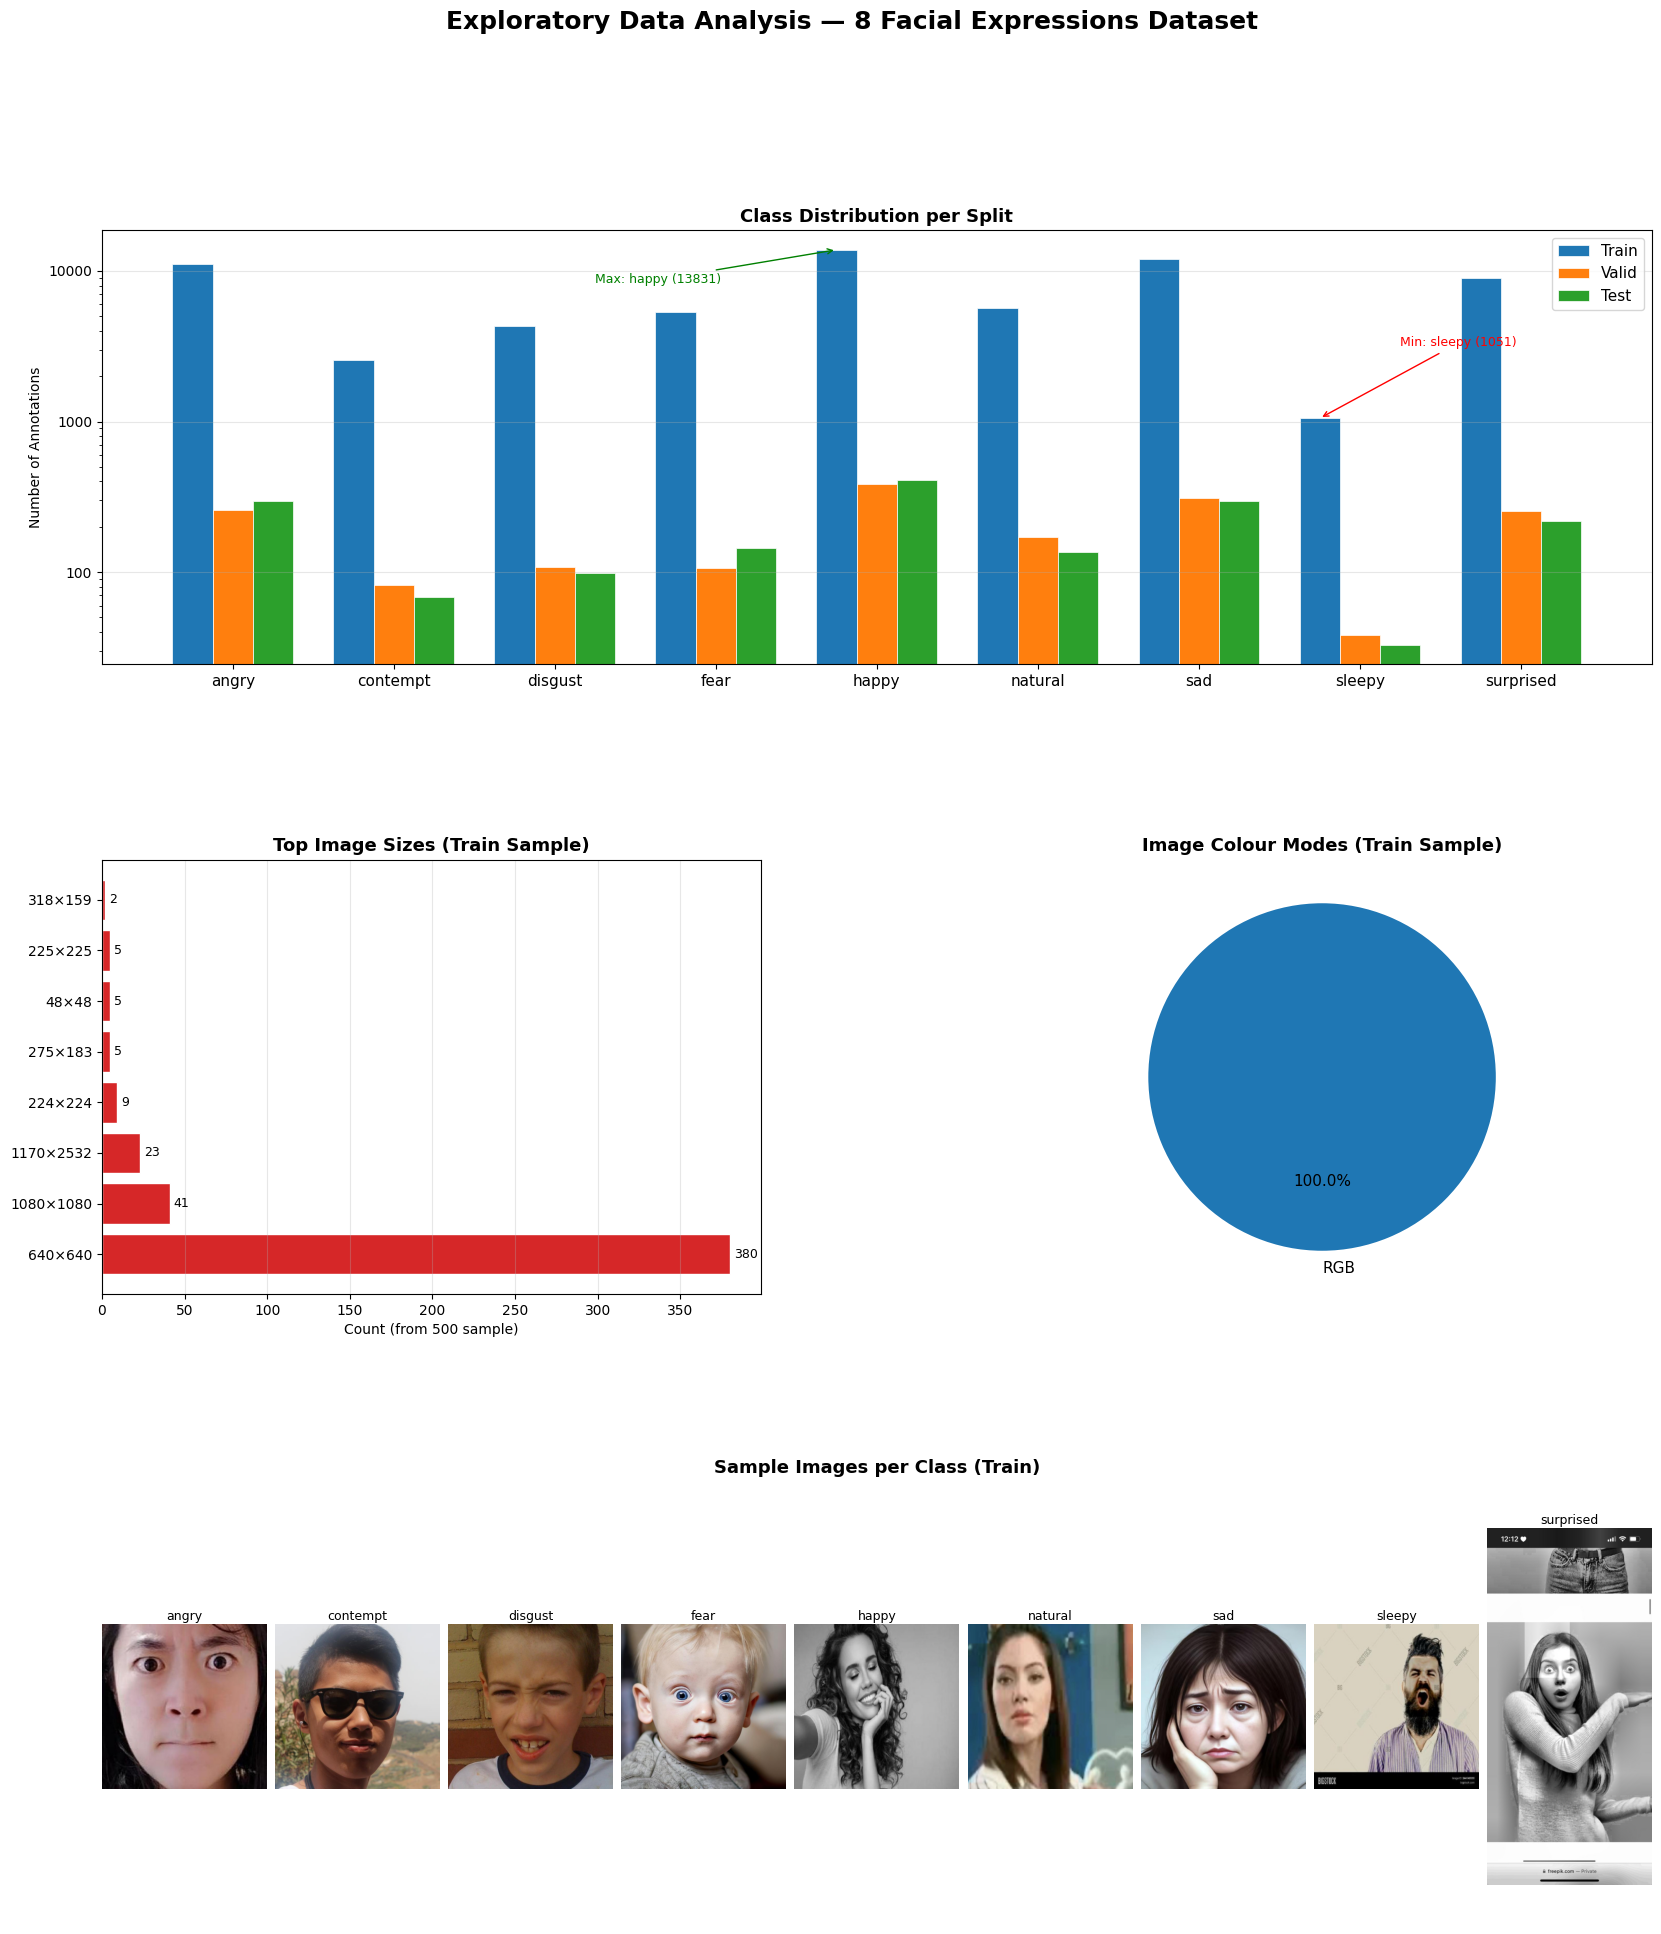

Saved to eda_report.png


In [11]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import Counter
from PIL import Image
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
base = f"{path}/9 Facial Expressions you need"
splits = ["train", "valid", "test"]
classes = ['angry', 'contempt', 'disgust', 'fear', 'happy', 'natural', 'sad', 'sleepy', 'surprised']
colors  = plt.cm.tab10.colors

# ── Collect data ──────────────────────────────────────────────────────────────
class_counts = {}
for split in splits:
    label_dir = f"{base}/{split}/labels"
    counts = Counter()
    for lf in os.listdir(label_dir):
        with open(f"{label_dir}/{lf}") as f:
            for line in f:
                cls = int(line.strip().split()[0])
                counts[cls] += 1
    class_counts[split] = [counts.get(i, 0) for i in range(len(classes))]

# Image sizes & modes from train sample
img_dir = f"{base}/train/images"
sample_files = os.listdir(img_dir)[:500]
sizes, modes = [], []
for fn in sample_files:
    img = Image.open(f"{img_dir}/{fn}")
    sizes.append(img.size)
    modes.append(img.mode)

size_counts = Counter(sizes).most_common(8)
mode_counts = Counter(modes)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.suptitle("Exploratory Data Analysis — 8 Facial Expressions Dataset", fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Class distribution per split (grouped bar) ────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(classes))
w = 0.25
for i, split in enumerate(splits):
    ax1.bar(x + i*w, class_counts[split], width=w, label=split.capitalize(),
            color=colors[i], edgecolor='white', linewidth=0.5)
ax1.set_xticks(x + w)
ax1.set_xticklabels(classes, fontsize=11)
ax1.set_ylabel("Number of Annotations")
ax1.set_title("Class Distribution per Split", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(plt.ScalarFormatter())
ax1.grid(axis='y', alpha=0.3)

# imbalance annotation
min_cls = classes[np.argmin(class_counts["train"])]
max_cls = classes[np.argmax(class_counts["train"])]
ax1.annotate(f"Min: {min_cls} ({min(class_counts['train'])})",
             xy=(classes.index(min_cls), min(class_counts['train'])),
             xytext=(classes.index(min_cls)+0.5, min(class_counts['train'])*3),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax1.annotate(f"Max: {max_cls} ({max(class_counts['train'])})",
             xy=(classes.index(max_cls), max(class_counts['train'])),
             xytext=(classes.index(max_cls)-1.5, max(class_counts['train'])*0.6),
             arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)

# ── 2. Image size distribution ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
size_labels = [f"{w}×{h}" for (w, h), _ in size_counts]
size_vals   = [c for _, c in size_counts]
bars = ax2.barh(size_labels, size_vals, color=colors[3], edgecolor='white')
ax2.set_xlabel("Count (from 500 sample)")
ax2.set_title("Top Image Sizes (Train Sample)", fontsize=13, fontweight='bold')
ax2.bar_label(bars, padding=3, fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# ── 3. Image mode distribution (pie) ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
mode_labels = list(mode_counts.keys())
mode_vals   = list(mode_counts.values())
wedges, texts, autotexts = ax3.pie(
    mode_vals, labels=mode_labels, autopct='%1.1f%%',
    colors=[colors[i] for i in range(len(mode_labels))],
    startangle=90, textprops={'fontsize': 11}
)
ax3.set_title("Image Colour Modes (Train Sample)", fontsize=13, fontweight='bold')

# ── 4. Sample image grid ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')
ax4.set_title("Sample Images per Class (Train)", fontsize=13, fontweight='bold', pad=12)

# build inner grid: 1 row x 9 cols
inner = gridspec.GridSpecFromSubplotSpec(1, len(classes), subplot_spec=gs[2, :], wspace=0.05)

label_dir = f"{base}/train/labels"
img_dir   = f"{base}/train/images"

# map class_id -> list of image stems
cls_to_imgs = {i: [] for i in range(len(classes))}
for lf in os.listdir(label_dir):
    stem = os.path.splitext(lf)[0]
    with open(f"{label_dir}/{lf}") as f:
        lines = f.readlines()
    if lines:
        cls_id = int(lines[0].strip().split()[0])
        cls_to_imgs[cls_id].append(stem)

for i, cls_name in enumerate(classes):
    ax = fig.add_subplot(inner[i])
    stems = cls_to_imgs[i]
    if stems:
        stem = random.choice(stems)
        # try common extensions
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
            candidate = f"{img_dir}/{stem}{ext}"
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
    ax.set_title(cls_name, fontsize=9, pad=3)
    ax.axis('off')

plt.savefig("eda_report.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved to eda_report.png")

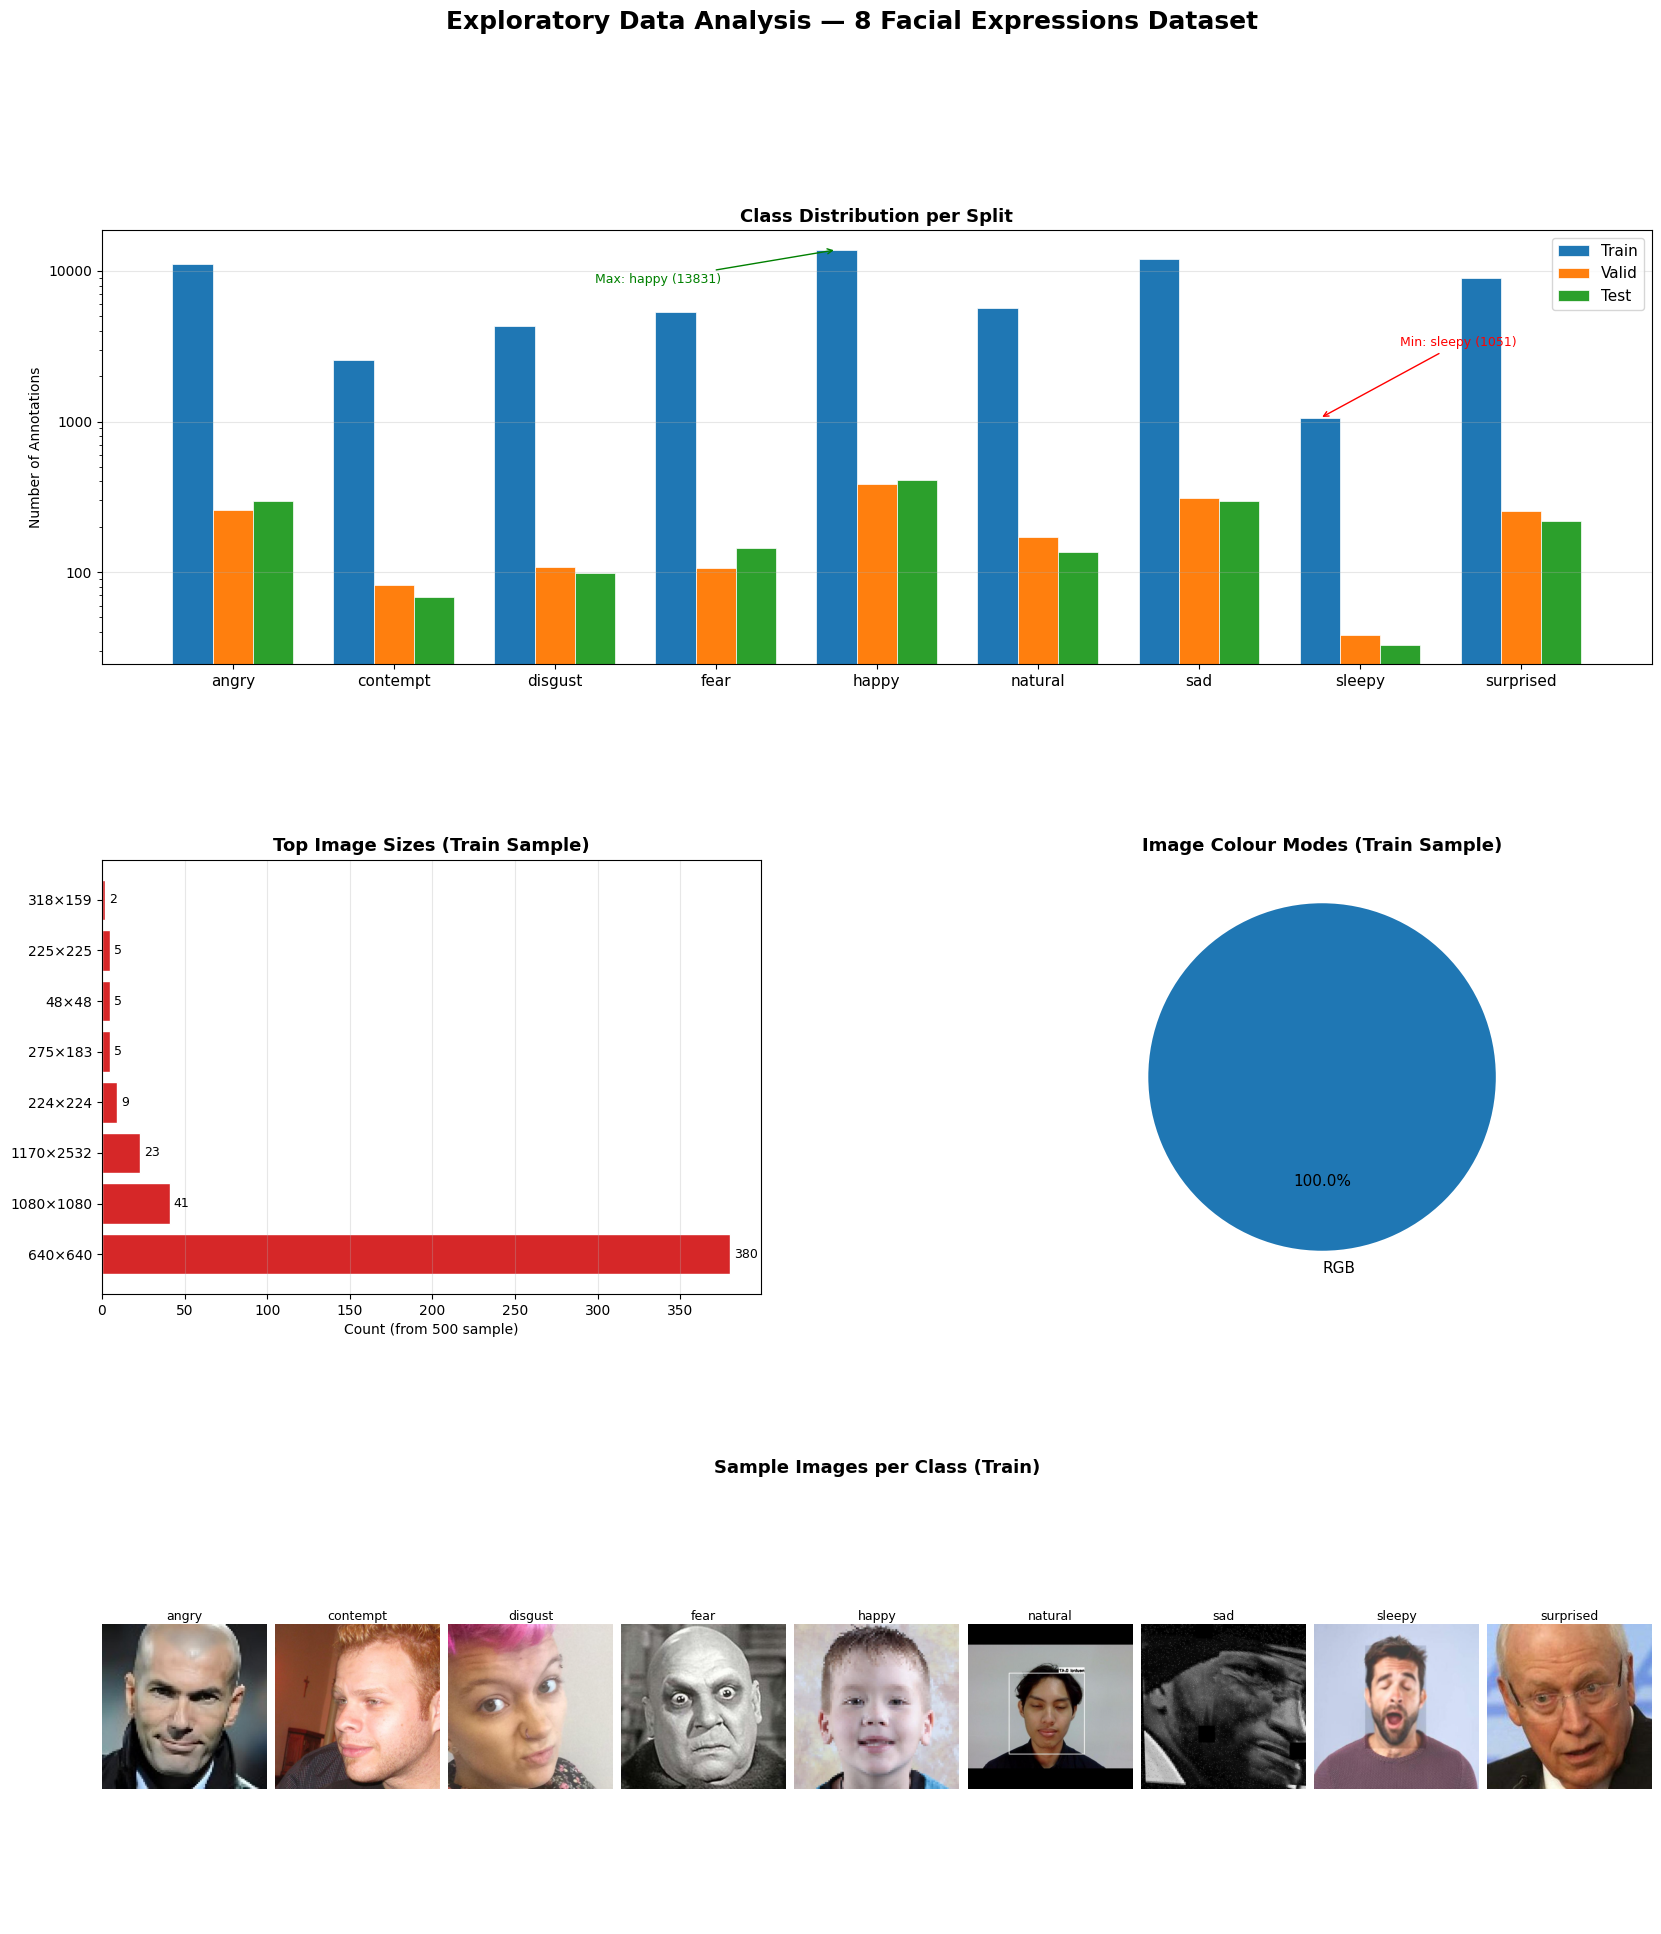

Saved to eda_report.png


In [12]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import Counter
from PIL import Image
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
base = f"{path}/9 Facial Expressions you need"
splits = ["train", "valid", "test"]
classes = ['angry', 'contempt', 'disgust', 'fear', 'happy', 'natural', 'sad', 'sleepy', 'surprised']
colors  = plt.cm.tab10.colors

# ── Collect data ──────────────────────────────────────────────────────────────
class_counts = {}
for split in splits:
    label_dir = f"{base}/{split}/labels"
    counts = Counter()
    for lf in os.listdir(label_dir):
        with open(f"{label_dir}/{lf}") as f:
            for line in f:
                cls = int(line.strip().split()[0])
                counts[cls] += 1
    class_counts[split] = [counts.get(i, 0) for i in range(len(classes))]

# Image sizes & modes from train sample
img_dir = f"{base}/train/images"
sample_files = os.listdir(img_dir)[:500]
sizes, modes = [], []
for fn in sample_files:
    img = Image.open(f"{img_dir}/{fn}")
    sizes.append(img.size)
    modes.append(img.mode)

size_counts = Counter(sizes).most_common(8)
mode_counts = Counter(modes)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.suptitle("Exploratory Data Analysis — 8 Facial Expressions Dataset", fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Class distribution per split (grouped bar) ────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(classes))
w = 0.25
for i, split in enumerate(splits):
    ax1.bar(x + i*w, class_counts[split], width=w, label=split.capitalize(),
            color=colors[i], edgecolor='white', linewidth=0.5)
ax1.set_xticks(x + w)
ax1.set_xticklabels(classes, fontsize=11)
ax1.set_ylabel("Number of Annotations")
ax1.set_title("Class Distribution per Split", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(plt.ScalarFormatter())
ax1.grid(axis='y', alpha=0.3)

# imbalance annotation
min_cls = classes[np.argmin(class_counts["train"])]
max_cls = classes[np.argmax(class_counts["train"])]
ax1.annotate(f"Min: {min_cls} ({min(class_counts['train'])})",
             xy=(classes.index(min_cls), min(class_counts['train'])),
             xytext=(classes.index(min_cls)+0.5, min(class_counts['train'])*3),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax1.annotate(f"Max: {max_cls} ({max(class_counts['train'])})",
             xy=(classes.index(max_cls), max(class_counts['train'])),
             xytext=(classes.index(max_cls)-1.5, max(class_counts['train'])*0.6),
             arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)

# ── 2. Image size distribution ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
size_labels = [f"{w}×{h}" for (w, h), _ in size_counts]
size_vals   = [c for _, c in size_counts]
bars = ax2.barh(size_labels, size_vals, color=colors[3], edgecolor='white')
ax2.set_xlabel("Count (from 500 sample)")
ax2.set_title("Top Image Sizes (Train Sample)", fontsize=13, fontweight='bold')
ax2.bar_label(bars, padding=3, fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# ── 3. Image mode distribution (pie) ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
mode_labels = list(mode_counts.keys())
mode_vals   = list(mode_counts.values())
wedges, texts, autotexts = ax3.pie(
    mode_vals, labels=mode_labels, autopct='%1.1f%%',
    colors=[colors[i] for i in range(len(mode_labels))],
    startangle=90, textprops={'fontsize': 11}
)
ax3.set_title("Image Colour Modes (Train Sample)", fontsize=13, fontweight='bold')

# ── 4. Sample image grid ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')
ax4.set_title("Sample Images per Class (Train)", fontsize=13, fontweight='bold', pad=12)

# build inner grid: 1 row x 9 cols
inner = gridspec.GridSpecFromSubplotSpec(1, len(classes), subplot_spec=gs[2, :], wspace=0.05)

label_dir = f"{base}/train/labels"
img_dir   = f"{base}/train/images"

# map class_id -> list of image stems
cls_to_imgs = {i: [] for i in range(len(classes))}
for lf in os.listdir(label_dir):
    stem = os.path.splitext(lf)[0]
    with open(f"{label_dir}/{lf}") as f:
        lines = f.readlines()
    if lines:
        cls_id = int(lines[0].strip().split()[0])
        cls_to_imgs[cls_id].append(stem)

for i, cls_name in enumerate(classes):
    ax = fig.add_subplot(inner[i])
    stems = cls_to_imgs[i]
    if stems:
        stem = random.choice(stems)
        # try common extensions
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
            candidate = f"{img_dir}/{stem}{ext}"
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
    ax.set_title(cls_name, fontsize=9, pad=3)
    ax.axis('off')

plt.savefig("eda_report.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved to eda_report.png")